# Final

In [235]:
import numpy as np
import matplotlib.pyplot as plt

## Problem F.2

In [236]:
N = 2**10
A = np.random.uniform(-1, 1, size=(N, N))
B = np.random.uniform(-1, 1, size=(N, N))


In [237]:
def pad_matrix(matrix):
    n = len(matrix)
    m = len(matrix[0])
    size = 1
    while size < max(n, m):
        size *= 2
    
    padded = [[0 for _ in range(size)] for _ in range(size)]
    for i in range(n):
        for j in range(m):
            padded[i][j] = matrix[i][j]
    return padded, size

def strassen_multiply(A, B):
    n = len(A)
    
    if n == 1:
        return [[A[0][0] * B[0][0]]]
    
    mid = n // 2
    a11 = [[A[i][j] for j in range(mid)] for i in range(mid)]
    a12 = [[A[i][j] for j in range(mid, n)] for i in range(mid)]
    a21 = [[A[i][j] for j in range(mid)] for i in range(mid, n)]
    a22 = [[A[i][j] for j in range(mid, n)] for i in range(mid, n)]
    
    b11 = [[B[i][j] for j in range(mid)] for i in range(mid)]
    b12 = [[B[i][j] for j in range(mid, n)] for i in range(mid)]
    b21 = [[B[i][j] for j in range(mid)] for i in range(mid, n)]
    b22 = [[B[i][j] for j in range(mid, n)] for i in range(mid, n)]
    
    def matrix_add(X, Y):
        return [[X[i][j] + Y[i][j] for j in range(len(X[0]))] for i in range(len(X))]
    
    def matrix_subtract(X, Y):
        return [[X[i][j] - Y[i][j] for j in range(len(X[0]))] for i in range(len(X))]
    
    m1 = strassen_multiply(matrix_add(a11, a22), matrix_add(b11, b22))
    m2 = strassen_multiply(matrix_add(a21, a22), b11)
    m3 = strassen_multiply(a11, matrix_subtract(b12, b22))
    m4 = strassen_multiply(a22, matrix_subtract(b21, b11))
    m5 = strassen_multiply(matrix_add(a11, a12), b22)
    m6 = strassen_multiply(matrix_subtract(a21, a11), matrix_add(b11, b12))
    m7 = strassen_multiply(matrix_subtract(a12, a22), matrix_add(b21, b22))
    
    c11 = matrix_add(matrix_subtract(matrix_add(m1, m4), m5), m7)
    c12 = matrix_add(m3, m5)
    c21 = matrix_add(m2, m4)
    c22 = matrix_add(matrix_subtract(matrix_add(m1, m3), m2), m6)
    
    C = [[0 for _ in range(n)] for _ in range(n)]
    for i in range(mid):
        for j in range(mid):
            C[i][j] = c11[i][j]
            C[i][j + mid] = c12[i][j]
            C[i + mid][j] = c21[i][j]
            C[i + mid][j + mid] = c22[i][j]
    
    return C

def matrix_multiply_strassen(A, B):
    if len(A[0]) != len(B):
        raise ValueError("Matrix dimensions do not match for multiplication")
    
    A_padded, _ = pad_matrix(A)
    B_padded, _ = pad_matrix(B)
    
    result_padded = strassen_multiply(A_padded, B_padded)
    
    result = [[result_padded[i][j] for j in range(len(B[0]))] for i in range(len(A))]
    return result

In [238]:
C = matrix_multiply_strassen(A, B)
    
A_np = np.array(A)
B_np = np.array(B) 
C_np = np.matmul(A_np, B_np)

C_strassen = np.array(C)
is_equal = np.allclose(C_strassen, C_np)
print(f"\nStrassen result matches numpy: {is_equal}")
print("Maximum difference:", np.max(np.abs(C_strassen - C_np)))



Strassen result matches numpy: True
Maximum difference: 5.728750807065808e-14


In [239]:
def gaussian_elimination(A, b):
    N = len(A)
    # Combine A and b to create an augmented matrix
    augmented = np.column_stack((A, b))
    # Forward elimination
    for i in range(N):
        # Find the pivot row
        max_row = i
        max_val = abs(augmented[i, i])
        for k in range(i + 1, N):
            if abs(augmented[k, i]) > max_val:
                max_row = k
                max_val = abs(augmented[k, i])
        
        # Swap the current row with the pivot row if necessary
        if max_row != i:
            augmented[[i, max_row]] = augmented[[max_row, i]]
        
        # Eliminate entries below the pivot
        for j in range(i + 1, N):
            factor = augmented[j, i] / augmented[i, i]
            augmented[j, i :] -= factor * augmented[i, i :]
    
    # Back substitution
    x = [0.0] * N
    for i in range(N - 1, -1, -1):
        x[i] = float((augmented[i, N] - np.dot(augmented[i, i + 1 : N], x[i + 1 :])) / augmented[i, i])
    
    return x

In [240]:
n = len(C)
C_inv = np.zeros((n, n))
# Solve for each column of the inverse
for i in range(n):
    b = np.zeros(n)
    b[i] = 1
    C_inv[:, i] = gaussian_elimination(C, b)
    
print("\nInverse of C:")
print(C_inv)

# Verify that C * C^-1 ≈ I
product = np.matmul(C, C_inv)
is_identity = np.allclose(product, np.eye(n))
print(f"\nC * C^-1 is identity matrix: {is_identity}")
print("Maximum difference from identity:", np.max(np.abs(product - np.eye(n))))


Inverse of C:
[[ 4.67238942e-01  5.46473597e-01  2.43354227e-01 ...  1.69201928e-01
   3.12078241e-03 -1.87567887e-02]
 [-6.04614189e-01 -4.81175793e-01 -1.07900888e-01 ...  5.09965246e-01
   3.18940736e-02 -1.18737254e-01]
 [ 3.78900144e-01  1.94569156e-01  1.87860828e-01 ... -1.25523818e+00
   1.42624455e-01  1.58822449e-01]
 ...
 [-5.49906036e-01 -1.61769346e-01 -4.45621647e-01 ...  1.80420461e+00
  -2.99329983e-01 -2.49339138e-01]
 [ 2.14309581e+00  1.03684034e+00  1.19696098e+00 ... -4.22402538e+00
   9.21094383e-01  6.29369548e-01]
 [ 9.10346311e-01  4.80355632e-01  4.03489061e-01 ... -1.42081699e+00
   4.65959908e-01  1.55909066e-01]]

C * C^-1 is identity matrix: True
Maximum difference from identity: 3.377855998816477e-14


## Problem F.3

In [241]:
N = 10**4
x0 = 1
h = 5 / N

In [242]:
def newton(fun, fun_prime, x0 = 0, tol = 5e-5, max = 100):
    i = 0
    while i < max:
        i += 1
        x1 = x0 - fun(x0) / fun_prime(x0)
        if abs(x1 - x0) < tol:
            return x1
        x0 = x1
    raise RuntimeError

def RK4(x0, xn, y0, n, slope):
    x = np.linspace(x0, xn, n)
    h = (xn - x0) / (n - 1)
    y = np.zeros(n)
    y[0] = y0
    
    for i in range(n - 1):
        k1 = slope(x[i], y[i])
        k2 = slope(x[i] + h / 2, y[i] + h * k1 / 2)
        k3 = slope(x[i] + h / 2, y[i] + h * k2 / 2)
        k4 = slope(x[i] + h, y[i] + h * k3)
        k = (k1 + 2 * k2 + 2 * k3 + k4) / 6
        y[i + 1] = y[i] + h * k
    
    return x, y



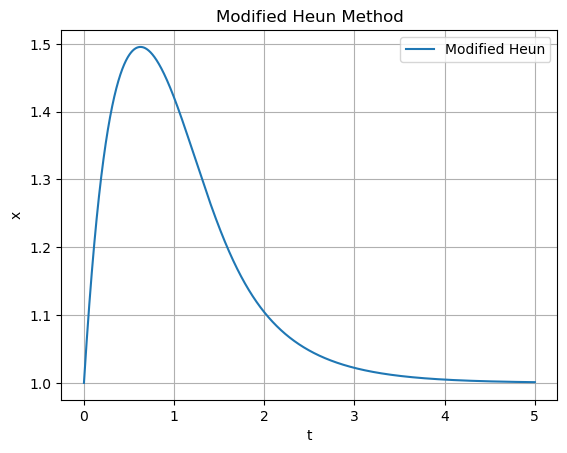

In [243]:
def Modified_Heun(t0, tn, x0, n):
    t = np.linspace(t0, tn, n)
    h = (tn - t0) / (n - 1)
    x = np.zeros(n)
    x[0] = x0

    for i in range(n - 1):
        # Calculate k1 (slope at current point)
        slope = lambda xp: np.exp(-xp) - xp - x[i]**3 + 3 * np.exp(-t[i]**3)
        slope_prime = lambda xp: -np.exp(-xp) - 1
        k1 = newton(slope, slope_prime)

        # Calculate k2 (slope at next point) using RK1
        next_t = t[i] + h
        next_x = x[i] + h * k1
        slope_h = lambda xp: np.exp(-xp) - xp - next_x**3 + 3 * np.exp(-next_t**3)
        k2 = newton(slope_h, slope_prime)

        x[i + 1] = x[i] + h * (k1 + k2) / 2
    
    return t, x

t, x = Modified_Heun(0, 5, 1, N)
plt.figure()
plt.plot(t, x, label='Modified Heun')
plt.xlabel('t')
plt.ylabel('x')
plt.title('Modified Heun Method')
plt.grid(True)
plt.legend()
plt.show()


P5 polynomial coefficients (from highest to lowest degree):
x^5: 0.010494
x^4: -0.152476
x^3: 0.814396
x^2: -1.901736
x^1: 1.649891
x^0: 1.000000


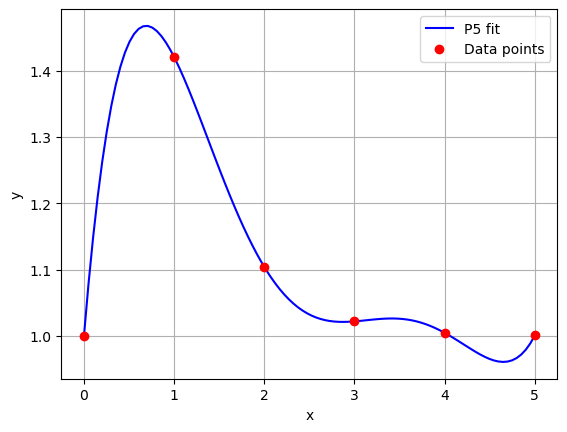

In [244]:
points = {0: x[0], 1: x[N//5], 2: x[2*N//5], 3: x[3*N//5], 4: x[4*N//5], 5: x[N-1]}

def fit(points):
    # calculation for A^T * A
    n = len(points)
    sum_x10 = sum(t**10 for t in points.keys())
    sum_x9 = sum(t**9 for t in points.keys())
    sum_x8 = sum(t**8 for t in points.keys())
    sum_x7 = sum(t**7 for t in points.keys())
    sum_x6 = sum(t**6 for t in points.keys())
    sum_x5 = sum(t**5 for t in points.keys())
    sum_x4 = sum(t**4 for t in points.keys())
    sum_x3 = sum(t**3 for t in points.keys())
    sum_x2 = sum(t**2 for t in points.keys())
    sum_x = sum(points.keys())
    sum_y = sum(points.values())
    sum_xy = sum(p * points[p] for p in points)
    sum_x2y = sum(p**2 * points[p] for p in points)
    sum_x3y = sum(p**3 * points[p] for p in points)
    sum_x4y = sum(p**4 * points[p] for p in points)
    sum_x5y = sum(p**5 * points[p] for p in points)

    # Set up system for P5 fit (6 coefficients)
    LHS = [
        [sum_x10, sum_x9, sum_x8, sum_x7, sum_x6, sum_x5],
        [sum_x9, sum_x8, sum_x7, sum_x6, sum_x5, sum_x4],
        [sum_x8, sum_x7, sum_x6, sum_x5, sum_x4, sum_x3],
        [sum_x7, sum_x6, sum_x5, sum_x4, sum_x3, sum_x2],
        [sum_x6, sum_x5, sum_x4, sum_x3, sum_x2, sum_x],
        [sum_x5, sum_x4, sum_x3, sum_x2, sum_x, n]
    ]
    RHS = [sum_x5y, sum_x4y, sum_x3y, sum_x2y, sum_xy, sum_y]
    
    # Solve using Gaussian elimination
    coefficients = gaussian_elimination(LHS, RHS)

    return coefficients

# Plot P5 polynomial fit
x_plot = np.linspace(min(points.keys()), max(points.keys()), 100)
coeffs = fit(points)
print("P5 polynomial coefficients (from highest to lowest degree):")
for i, c in enumerate(coeffs):
    print(f"x^{5-i}: {c:.6f}")

y_plot = [sum(c * x**i for i, c in enumerate(coeffs[::-1])) for x in x_plot]

plt.figure()
plt.plot(x_plot, y_plot, 'b-', label='P5 fit')
plt.plot(list(points.keys()), list(points.values()), 'ro', label='Data points')
plt.xlabel('x')
plt.ylabel('y') 
plt.legend()
plt.grid(True)
plt.show()



Fitted parameters:
α = 2.000000
β = 1.684211


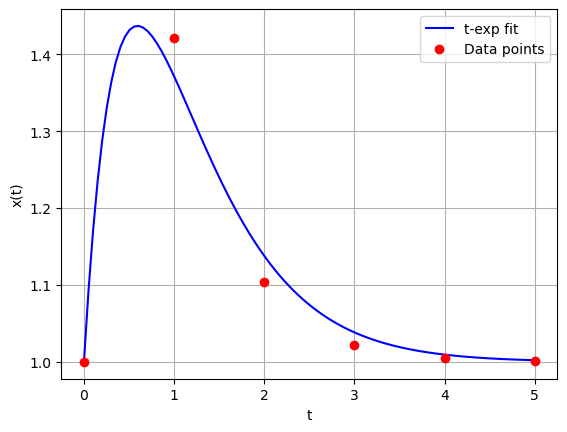

In [245]:
def t_exp_fit(t, alpha, beta):
    return 1 + alpha * t * np.exp(-beta * t)

def error_func(params, points):
    alpha, beta = params
    error = 0
    for t, x in points.items():
        error += (t_exp_fit(t, alpha, beta) - x)**2
    return error

initial_guess = [1.0, 1.0]
alpha_opt = 0
beta_opt = 0
min_error = float('inf')

for alpha in np.linspace(0, 2, 20):
    for beta in np.linspace(0, 2, 20):
        err = error_func([alpha, beta], points)
        if err < min_error:
            min_error = err
            alpha_opt = alpha
            beta_opt = beta

result = type('Result', (), {'x': [alpha_opt, beta_opt]})()
alpha_fit, beta_fit = result.x

print(f"Fitted parameters:")
print(f"α = {alpha_fit:.6f}")
print(f"β = {beta_fit:.6f}")

x_plot = np.linspace(min(points.keys()), max(points.keys()), 100)
y_plot = [t_exp_fit(x, alpha_fit, beta_fit) for x in x_plot]

plt.figure()
plt.plot(x_plot, y_plot, 'b-', label='t-exp fit')
plt.plot(list(points.keys()), list(points.values()), 'ro', label='Data points')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.legend()
plt.grid(True)
plt.show()


## Problem F.4

In [246]:
f = lambda x, y: -x * y
y0 = 1
y2 = 2

In [247]:
def newton(fun, fun_prime, x0 = 0, tol = 5e-5, max = 100):
    i = 0
    while i < max:
        i += 1
        x1 = x0 - fun(x0) / fun_prime(x0)
        if abs(x1 - x0) < tol:
            return x1
        x0 = x1
    raise RuntimeError

def rk4_system(x0, xn, y0, slope, n, f):
    x = np.linspace(x0, xn, n)
    h = (xn - x0) / (n - 1)
    y = np.zeros(n)
    y[0] = y0
    
    for i in range(n - 1):
        k1_y = slope
        k1_s = f(x[i], y[i])
        
        k2_y = slope + h * k1_s / 2
        k2_s = f(x[i] + h/2, y[i] + h * k1_y / 2)
        
        k3_y = slope + h * k2_s / 2  
        k3_s = f(x[i] + h/2, y[i] + h * k2_y / 2)
        
        k4_y = slope + h * k3_s
        k4_s = f(x[i] + h, y[i] + h * k3_y)
        
        y[i + 1] = y[i] + h * (k1_y + 2*k2_y + 2*k3_y + k4_y) / 6
        slope = slope + h * (k1_s + 2*k2_s + 2*k3_s + k4_s) / 6
        
    return x, y

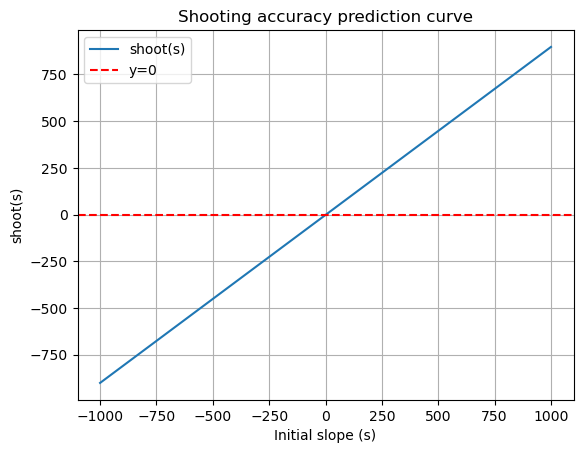

There is only one solution: s = 2.240906843463551


In [248]:
def shoot(s):
    x, y = rk4_system(0, 2, y0, s, 200, f)
    return y[-1] - y2

def shoot_prime(s, h = 1e-10):
    return (shoot(s + h) - shoot(s - h)) / (2 * h)

s_range = np.linspace(-1000, 1000, 200)
shoot_values = [shoot(s_val) for s_val in s_range]

plt.figure()
plt.plot(s_range, shoot_values, label='shoot(s)')
plt.axhline(y=0, color='r', linestyle='--', label='y=0')
plt.xlabel('Initial slope (s)')
plt.ylabel('shoot(s)')
plt.title('Shooting accuracy prediction curve')
plt.legend()
plt.grid(True)
plt.show()

s = newton(shoot, shoot_prime, x0 = 0)
print(f"There is only one solution: s = {s}")



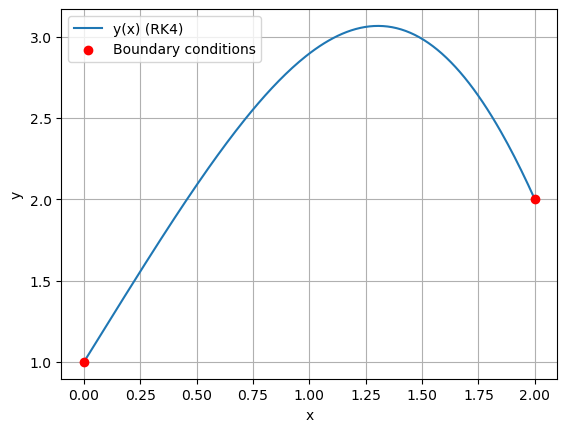


Solution Table:
   x      y
---------------
  0.00   1.000
  0.01   1.023
  0.02   1.045
  0.03   1.068
  0.04   1.090
  0.05   1.113
  0.06   1.135
  0.07   1.158
  0.08   1.180
  0.09   1.203
  0.10   1.225
  0.11   1.247
  0.12   1.270
  0.13   1.292
  0.14   1.315
  0.15   1.337
  0.16   1.360
  0.17   1.382
  0.18   1.404
  0.19   1.427
  0.20   1.449
  0.21   1.471
  0.22   1.493
  0.23   1.515
  0.24   1.538
  0.25   1.560
  0.26   1.582
  0.27   1.604
  0.28   1.626
  0.29   1.648
  0.30   1.670
  0.31   1.691
  0.32   1.713
  0.33   1.735
  0.34   1.757
  0.35   1.778
  0.36   1.800
  0.37   1.821
  0.38   1.843
  0.39   1.864
  0.40   1.885
  0.41   1.906
  0.42   1.927
  0.43   1.949
  0.44   1.969
  0.45   1.990
  0.46   2.011
  0.47   2.032
  0.48   2.052
  0.49   2.073
  0.50   2.093
  0.51   2.113
  0.52   2.134
  0.53   2.154
  0.54   2.174
  0.55   2.193
  0.56   2.213
  0.57   2.233
  0.58   2.252
  0.59   2.271
  0.60   2.290
  0.61   2.309
  0.62   2.328
  0.63   2

In [249]:
x, y = rk4_system(0, 2, y0, s, 200, f)

plt.plot(x, y, label='y(x) (RK4)')
plt.scatter([0, 2], [y0, y2], color='red', zorder=5, label='Boundary conditions')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

print("\nSolution Table:")
print("   x      y")
print("-" * 15)
for i in range(0, len(x)):
    print(f"{x[i]:6.2f}  {y[i]:6.3f}")

